In [1]:
#Context: I ran on modal.com on L4 GPU but faced issue so runnning this again on colab with T4 GPU

# Fusemachines AI Fellowship 2026
> ## Agentic Routing with LLMs & Transformers

**Topic:** Transformers, LLMs, and Foundation Models
**File to submit:** `<your_name>_support_routing.ipynb`: must run top-to-bottom without errors.

## 0. Assignment Overview

**Scenario.** You are on the AI engineering team at **ShopAssist AI**. Before any specialized
support agent can respond to a customer, an incoming message has to be **routed** to exactly
one of 11 agents. Your job is to prototype and benchmark **two** routing strategies and
recommend one for production.

| Agent | Intents it owns |
|---|---|
| ACCOUNT | create_account, delete_account, edit_account, switch_account |
| CANCEL | check_cancellation_fee |
| CONTACT | contact_customer_service, contact_human_agent |
| DELIVERY | delivery_options |
| FEEDBACK | complaint, review |
| INVOICE | check_invoice, get_invoice |
| SUBSCRIPTION | newsletter_subscription |
| ORDER | cancel_order, change_order, place_order |
| PAYMENT | check_payment_methods, payment_issue |
| REFUND | check_refund_policy, track_refund |
| SHIPPING | change_shipping_address, set_up_shipping_address |

**Dataset.** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — use the `category`
column directly as your 11-class target (`instruction` is the customer message).


**What you will build:**
1. **Approach 1** — fine-tune an encoder-only transformer (BERT-family) as a `[CLS]`-token classifier.
2. **Approach 2** — fine-tune a decoder-only SLM (Qwen) to *generate* the agent name as a single token, optionally with LoRA.
3. A **comparison** of both approaches on the *same* held-out test set, a **recommendation**, and a **reflection**.

**Every `# TODO` marker in this notebook is something you need to implement.** Helper functions are provided so you can focus on the modeling decisions that matter for this topic (tokenization, model setup, training configuration, evaluation, and interpreting results).

## Setup

In [2]:
# 0. Setup and Installations
!pip install -q transformers datasets evaluate peft accelerate trl scikit-learn matplotlib seaborn pandas
!pip install -U -q bitsandbytes
!pip install -q -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 36.9 MB/s eta 0:00:00


## 1. Global Configuration

Read it carefully, since `TARGET_CATEGORIES`, `label2id`, `id2label`, and `NUM_LABELS` are used by **both** approaches below.

In [3]:
import torch
import gc
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, ClassLabel, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

RANDOM_SEED = 0
HF_DATA_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

# The 11 support agents == the 11 categories in the dataset (see Section 0 table).
TARGET_CATEGORIES = [
    'ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE',
    'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION'
]
NUM_LABELS = len(TARGET_CATEGORIES)
assert NUM_LABELS == 11, "Expected exactly 11 support agents / categories"

# If a model you pick requires authentication (gated repo), log in
# INTERACTIVELY -- never hardcode a token in a notebook you submit or share:
#
#   from huggingface_hub import login
#   login()   # prompts for a token, or reads the HF_TOKEN env var
#
# None of the candidate models below require this, so it's commented out.

Using device: cuda
Tesla T4


## 2. Helper Functions

These are given so both approaches can share identical:
- `get_metrics`: macro precision/recall/F1 + accuracy.
- `get_stratified_splits`: builds **one** train/validation/test split that Approach 1 and Approach 2 will **both** reuse (this is what guarantees "both approaches are evaluated on the same held-out test set").
- `plot_loss_curve`: plots train vs. validation loss from a `Trainer`'s `log_history`.
- `plot_confusion_matrix_heatmap`: confusion matrix heatmap for either integer or string labels.
- `measure_latency_and_memory`: times batch-size-1 inference and logs peak CUDA memory, after a short warm-up (so the first, slower CUDA-kernel-compilation call doesn't skew results).

In [4]:
def get_metrics(labels, preds):
    """
    Calculates macro-averaged evaluation metrics for classification.

    Args:
        labels: True ground truth labels.
        preds: Predicted labels from the model.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }


def get_stratified_splits(dataset_id, target_categories, seed=RANDOM_SEED,
                           train_frac=0.8, val_frac=0.1, test_frac=0.1):
    """
    Loads the Bitext dataset, filters to `target_categories`, and returns a single
    stratified train/validation/test DatasetDict
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    label2id = {c: i for i, c in enumerate(target_categories)}
    id2label = {i: c for c, i in label2id.items()}

    dataset = load_dataset(dataset_id, split="train")
    dataset = dataset.filter(lambda x: x["category"] in target_categories)
    dataset = dataset.map(lambda x: {"label": label2id[x["category"]]})
    dataset = dataset.cast_column("label", ClassLabel(names=target_categories))

    holdout_frac = val_frac + test_frac
    train_holdout = dataset.train_test_split(test_size=holdout_frac, stratify_by_column="label", seed=seed)
    val_test = train_holdout["test"].train_test_split(
        test_size=test_frac / holdout_frac, stratify_by_column="label", seed=seed
    )

    splits = DatasetDict({
        "train": train_holdout["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })
    return splits, label2id, id2label


def plot_loss_curve(log_history, title="Training Loss"):
    """Given a HF Trainer's `trainer.state.log_history`, plot train vs. eval loss per step."""
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry.get("step", len(train_steps)))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry.get("step", len(eval_steps)))
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="s")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig('loss_curve.png', bbox_inches='tight', dpi=150)
    plt.show()


def plot_confusion_matrix_heatmap(labels, preds, class_names, title="Confusion Matrix"):
    """Confusion matrix heatmap. Works with integer labels or category-name strings."""
    use_names = isinstance(labels[0], str)
    cm = confusion_matrix(labels, preds, labels=class_names if use_names else list(range(len(class_names))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig('confusion_matrix_heatmap.png', bbox_inches='tight', dpi=150)
    plt.show()



def measure_latency_and_memory(predict_one_fn, examples, warmup=3):
    """
    Calls predict_one_fn(example) once per example (batch_size=1, matching a
    realistic single-request serving scenario). Resets CUDA peak-memory stats
    after warm-up so the very first (slow, kernel-compiling) call doesn't
    skew latency, and the reported peak memory reflects only steady-state
    inference.
    """
    examples = list(examples)
    for example in examples[:warmup]:
        _ = predict_one_fn(example)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    predictions = []
    start = time.time()
    for example in examples:
        predictions.append(predict_one_fn(example))
    end = time.time()

    avg_latency_ms = (end - start) / len(examples) * 1000
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    return avg_latency_ms, peak_mem_mb, predictions

# Approach 1: Fine-Tuning Encoder-Only Transformers

**Goal:** fine-tune one of the candidate encoders as a 11-class `[CLS]`-token classifier.

**You need to implement:**
- [X] Tokenization of the `instruction` field
- [X] Model + tokenizer loading (`AutoModelForSequenceClassification`, `num_labels=NUM_LABELS`)
- [X] `compute_metrics` for the `Trainer`
- [X] `TrainingArguments` (AdamW + linear warmup is the default optimizer/scheduler for `Trainer`)
- [X] Single-example inference function for latency/memory measurement
- [X] Loss curves, confusion matrix (required plots), inference latency, peak GPU memory (required to log)

**Candidate models** (pick at least one; report your best by test macro-F1):
`google-bert/bert-base-uncased`, `distilbert/distilbert-base-uncased`,
`FacebookAI/roberta-base`, `answerdotai/ModernBERT-base`

### 1. Data Loading & Preprocessing

In [5]:
# Build the ONE shared stratified split used by both Approach 1 and Approach 2.
splits, label2id, id2label = get_stratified_splits(
    dataset_id=HF_DATA_ID,
    target_categories=TARGET_CATEGORIES,
    seed=RANDOM_SEED,
    train_frac=0.8,
    val_frac=0.1,
    test_frac=0.1,
)

print(f"Train size: {len(splits['train'])} | Val size: {len(splits['validation'])} | Test size: {len(splits['test'])}")
print(splits)


Train size: 21497 | Val size: 2687 | Test size: 2688
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})


### 2. Fine-Tuning Encoder-Only Transformers

In [6]:
# Choose your encoder and load it

encoder_model_id = "distilbert/distilbert-base-uncased"  # fast, light, strong baseline -- good fit for a T4/L4 free-tier GPU

enc_tokenizer = AutoTokenizer.from_pretrained(encoder_model_id)

# Peek at how long a typical support message is (in tokens) before picking max_length --
# padding every example out to the model's full context window wastes compute for no reason.
_sample_lengths = [len(enc_tokenizer.encode(t)) for t in splits["train"]["instruction"][:2000]]
print(f"Instruction token length -- mean: {np.mean(_sample_lengths):.1f}, "
      f"95th pct: {np.percentile(_sample_lengths, 95):.0f}, max: {max(_sample_lengths)}")

# Bitext support queries are short (single sentence); 64 tokens comfortably covers the
# 95th percentile + [CLS]/[SEP] with headroom, while staying far cheaper than the model's
# full 512-token context.
ENC_MAX_LEN = 64

def tokenize_function(examples):
    return enc_tokenizer(examples["instruction"], truncation=True, max_length=ENC_MAX_LEN)

enc_tokenized = splits.map(tokenize_function, batched=True)
enc_data_collator = DataCollatorWithPadding(tokenizer=enc_tokenizer)

enc_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
).to(device)


Instruction token length -- mean: 13.0, 95th pct: 19, max: 31


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
# compute_metrics callback
def compute_metrics(eval_pred):
    """Unpack eval_pred into (logits, labels), argmax the logits (axis=-1), reuse get_metrics."""

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return get_metrics(labels, preds)

# ---- TrainingArguments + Trainer ----
enc_training_args = TrainingArguments(
    output_dir="./enc_results",
    learning_rate=2e-5,                # standard BERT-family fine-tuning LR
    per_device_train_batch_size=32,    # comfortably fits a T4/L4 for a 66M-param encoder
    per_device_eval_batch_size=32,
    num_train_epochs=3,                # short texts + 10 categories converge fast; watch val loss for overfitting
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_score",
    report_to="none",
)

enc_trainer = Trainer(
    model=enc_model,
    args=enc_training_args,
    train_dataset=enc_tokenized["train"],
    eval_dataset=enc_tokenized["validation"],
    processing_class=enc_tokenizer,
    data_collator=enc_data_collator,
    compute_metrics=compute_metrics,
)

print("Training Encoder Model...")
enc_trainer.train()


Training Encoder Model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score
1,0.017880,0.006050,0.999256,0.999393,0.999393,0.999392
2,0.003724,0.005145,0.998884,0.998634,0.999166,0.998897
3,0.001563,0.003946,0.998884,0.998634,0.999166,0.998897


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2016, training_loss=0.08495768501390037, metrics={'train_runtime': 175.2355, 'train_samples_per_second': 368.025, 'train_steps_per_second': 11.505, 'total_flos': 364758618275142.0, 'train_loss': 0.08495768501390037, 'epoch': 3.0})

### 3. Required Plot: Training & Validation Loss Curves

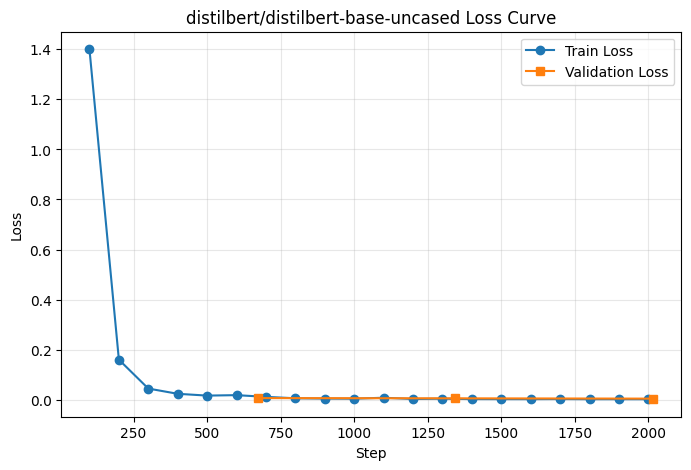

In [8]:
plot_loss_curve(enc_trainer.state.log_history, title=f"{encoder_model_id} Loss Curve")


### 4. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Write a **single-example** prediction function (batch size 1 -- this simulates a real routing
request) and feed it to `measure_latency_and_memory` together with `splits["test"]`.

In [9]:
def predict_one_encoder(example):
    """Tokenize a single instruction, run a forward pass, return the argmax label id."""
    inputs = enc_tokenizer(
        example["instruction"], return_tensors="pt", truncation=True, max_length=ENC_MAX_LEN
    ).to(device)
    with torch.no_grad():
        logits = enc_model(**inputs).logits
    return int(torch.argmax(logits, dim=-1).item())

enc_model.eval()
enc_latency, enc_peak_mem, enc_predictions = measure_latency_and_memory(
    predict_one_encoder, splits["test"]
)
enc_labels = splits["test"]["label"]

enc_metric_dict = get_metrics(enc_labels, enc_predictions)
enc_acc, enc_prec, enc_rec, enc_f1 = (enc_metric_dict["accuracy"], enc_metric_dict["precision"],
                                       enc_metric_dict["recall"], enc_metric_dict["f1_score"])

print(f"Encoder Macro-F1: {enc_f1:.4f}")
print(f"Encoder Latency: {enc_latency:.2f} ms/query")
print(f"Encoder Peak Memory: {enc_peak_mem:.2f} MB")


Encoder Macro-F1: 0.9987
Encoder Latency: 4.64 ms/query
Encoder Peak Memory: 789.21 MB


### 5. Required Plot: Confusion Matrix

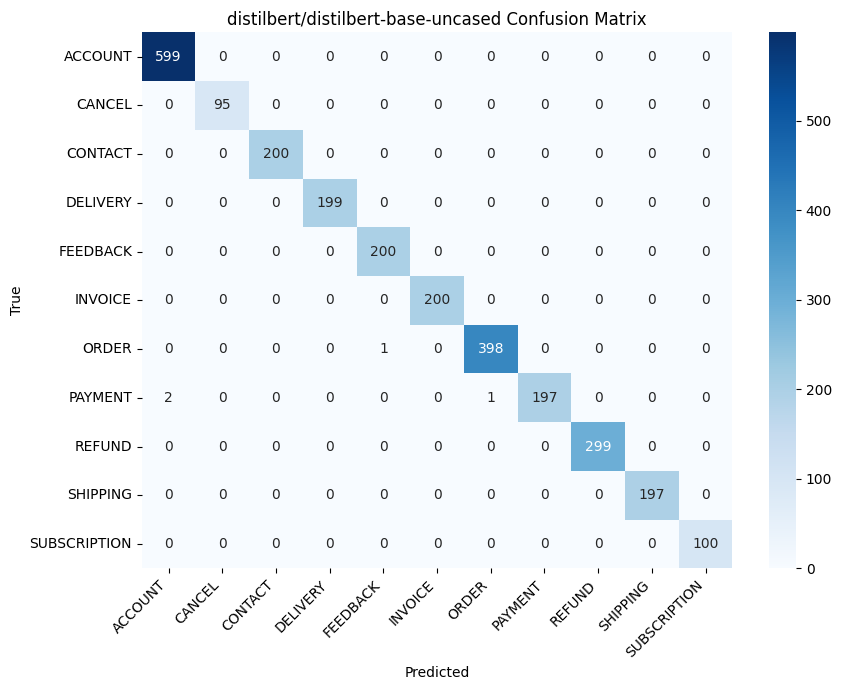

In [10]:
plot_confusion_matrix_heatmap(enc_labels, enc_predictions, TARGET_CATEGORIES,
                               title=f"{encoder_model_id} Confusion Matrix")


# Approach 2: Fine-Tuning Decoder-Only SLM (with / without LoRA)

**Goal:** treat routing as text generation; format each example as an instruction/response pair where the "response" is just the agent name (e.g. `REFUND`), then fine-tune a small decoder-only LM to produce it.

**You need to implement:**
- [X] Instruction-formatting function (`format_example`) using a chat template
- [X] Output parsing (`get_decoder_predictions`) that turns a raw generation into a clean label
- [X] Tokenization for training
- [X] LoRA config (or `USE_LORA=False` for full fine-tuning) + `TrainingArguments` + `SFTTrainer`
- [X] Loss curves, confusion matrix, inference latency, peak GPU memory (same requirements as Approach 1)

**Candidate models:** `Qwen/Qwen2.5-0.5B-Instruct`, `Qwen/Qwen2.5-1.5B-Instruct`

> **GPU memory note:** if you hit memory limits on a free-tier GPU (Colab T4, ~15 GB), use LoRA/QLoRA via `peft` (and consider 4-bit loading via `bitsandbytes`).

### 1. Model & Tokenizer Setup

In [11]:
# Choose your decoder model id
# If a candidate model is gated, authenticate INTERACTIVELY -- never hardcode
# a token in a notebook you submit or share:
#   from huggingface_hub import login; login()

decoder_model_id = "Qwen/Qwen2.5-0.5B-Instruct"  # smallest candidate -- cheapest to train/serve, still instruction-tuned
USE_LORA = True  # keeps memory low enough for a free-tier T4 (~15GB) and trains fast on an L4

dec_tokenizer = AutoTokenizer.from_pretrained(decoder_model_id, trust_remote_code=True)
# Some causal LMs ship without a pad token --
# set one if missing.
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

if USE_LORA:
    # QLoRA: load the base model in 4-bit (bitsandbytes) and only train LoRA adapters
    # on top. This is what keeps even the 4B candidate inside a free-tier T4's ~15GB.

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
    )
    dec_model = prepare_model_for_kbit_training(dec_model)
else:
    # Full fine-tuning: no quantization.
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, dtype=compute_dtype, device_map="auto", trust_remote_code=True,
    )

dec_model.config.use_cache = False   # required before training with gradient checkpointing


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

### 2. Loading & Formatting the Dataset

Reuse the **same** `splits` `DatasetDict` built in Approach 1's Data Loading step -- do **not**
call `load_dataset` again here. This is what keeps the two approaches' test sets identical.

In [12]:
print(splits)
print(splits["train"][0])

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
{'flags': 'BCLW', 'instruction': 'I want to retrieve the damn key of my user, I need help', 'category': 'ACCOUNT', 'intent': 'recover_password', 'response': "No worries at all! I'm here to provide the necessary assistance to retrieve the key of your user account. Let's tackle this together and get you back on track!", 'label': 0}


In [13]:
# Format each example as an instruction: single-token-label pair
SYS_PROMPT = (
    "You are an AI assistant trained for text classification; given any user "
    f"query, choose the single closest category from this fixed set: {TARGET_CATEGORIES}; "
    "output only the category name as the final answer without explanation or extra words."
)

def build_prompt(instruction_text):
    """Render the system + user turns with the model's own chat template."""
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": instruction_text},
    ]
    return dec_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def format_example(example):
    """
    1. Build the chat-templated prompt (system + user turn).
    2. The target is example["category"]
    3. Append the EOS token after the label so the model learns *where to stop*
       generating during training (otherwise it may run past the label).
    4. Return {"input_text": prompt + target + eos}.
    """
    prompt = build_prompt(example["instruction"])
    target = example["category"]

    return {"input_text": prompt + target + dec_tokenizer.eos_token}

# Apply it across every split, keeping the original instruction text around
formatted_splits = splits.map(
    lambda ex: {**format_example(ex), "original_text": ex["instruction"]}
)


### 3. Baseline Check: Zero-Shot Inference (Before Fine-Tuning)

In [14]:
# Given: greedy-decodes up to max_new_tokens tokens (a label is one word, so 5 is generous headroom).
def get_outputs(model, inputs, max_new_tokens=5):
    return model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        eos_token_id=dec_tokenizer.eos_token_id,
        pad_token_id=dec_tokenizer.pad_token_id,
        do_sample=False,
    )

def normalize_decoder_output(text, valid_categories=None):
    """Lowercase + strip everything but letters, then snap to a known category if the
    raw text contains one as a substring (handles the model echoing extra words/punctuation
    around the label). Falls back to the cleaned string, which will simply score as an
    incorrect prediction rather than crash the metric computation."""
    valid_categories = valid_categories or [c.lower() for c in TARGET_CATEGORIES]
    cleaned = re.sub(r"[^a-z]", "", text.lower())
    for cat in valid_categories:
        if cat in cleaned:
            return cat
    return cleaned

# TODO: turn a raw generation into a clean predicted category string
def get_decoder_predictions(dataset, model, batch_size=32):
    """Batched version: builds all prompts, generates in chunks instead of one row at a time."""
    model.eval()
    prompts = [build_prompt(row["original_text"]) for row in dataset]
    cats = [row["category"].lower() for row in dataset]

    # Left-padding is required for batched generation with a causal LM
    # otherwise the model's "current position" is misaligned across the batch.
    dec_tokenizer.padding_side = "left"

    labels, predictions = [], []
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i + batch_size]
        inputs = dec_tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)
        with torch.no_grad():
            output_ids = get_outputs(model, inputs)
        new_tokens = output_ids[:, inputs["input_ids"].shape[1]:]
        decoded_batch = dec_tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
        predictions.extend(normalize_decoder_output(d) for d in decoded_batch)
        labels.extend(cats[i:i + batch_size])

    dec_tokenizer.padding_side = "right"
    return labels, predictions

dec_labels, dec_preds = get_decoder_predictions(formatted_splits["test"], dec_model)
print("Zero-shot (pre-fine-tuning) baseline:", get_metrics(dec_labels, dec_preds))


Zero-shot (pre-fine-tuning) baseline: {'accuracy': 0.2864583333333333, 'precision': 0.04072522255363971, 'recall': 0.027539013584727677, 'f1_score': 0.027241876571628534}


### 4. Tokenization for Training

In [15]:
# Tokenize the formatted training data
_dec_lengths = [len(dec_tokenizer.encode(t)) for t in formatted_splits["train"]["input_text"][:1000]]
print(f"Formatted prompt+label token length -- mean: {np.mean(_dec_lengths):.1f}, "
      f"95th pct: {np.percentile(_dec_lengths, 95):.0f}, max: {max(_dec_lengths)}")

# Covers SYS_PROMPT (fixed, ~90 tokens incl. the category list) + longest instruction +
# label + EOS with comfortable headroom above the observed max.
DEC_MAX_LEN = 384

def tokenize_function(examples):
    """Tokenize examples["input_text"] with truncation to a fixed max_length."""
    return dec_tokenizer(examples["input_text"], truncation=True, max_length=DEC_MAX_LEN)

dec_tokenized = formatted_splits.map(tokenize_function, batched=True)


Formatted prompt+label token length -- mean: 106.7, 95th pct: 112, max: 117


### 5. LoRA Config & Training Arguments

In [16]:
import transformers, trl, peft, torch
print(f"transformers={transformers.__version__}  trl={trl.__version__}  peft={peft.__version__}  torch={torch.__version__}")

transformers=5.13.1  trl=1.10.0  peft=0.19.1  torch=2.11.0+cu128


In [22]:
peft_config = None
if USE_LORA:
    peft_config = LoraConfig(
        r=16,                  # good accuracy/efficiency trade-off for a 0.5B model
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",
    )



dec_train_args = TrainingArguments(
    output_dir=f"{decoder_model_id.split('/')[-1]}-router-finetuned/",
    per_device_train_batch_size=32,   # was 64 -- more margin now that the whole model sits on GPU
    per_device_eval_batch_size=64,    # no gradients during eval, so this could go higher, but no need to push it
    gradient_accumulation_steps=4,    # was 2 -- 32 * 4 = 128, same effective batch
    optim="adamw_torch_fused",        # fused kernel -- faster than plain adamw_torch, works fine on T4 too
    learning_rate=2e-4,               # typical LoRA LR -- higher than full fine-tuning since only adapters train
    max_grad_norm=0.1,
    num_train_epochs=3,
    warmup_steps=0.1,
    lr_scheduler_type="cosine",
    bf16=False,                    # CHANGED: was hardcoded True (L4-only) -- False on T4, avoids a hard error
    fp16=True,                # NEW: T4's actual mixed-precision path -- enables loss scaling automatically
    gradient_checkpointing=False,     # off -- a 0.5B model in fp16 fits T4's 15GB with plenty of room to spare
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="steps",            # NOTE: required so eval_loss appears in log_history for the loss-curve plot
    eval_steps=25,                   # ~20 eval points across 504 steps -- gives a real curve shape, not just 5 dots
    save_strategy="steps",
    save_steps=200,                   # infrequent saves -- each save briefly stalls training, so don't overdo it
    save_total_limit=2,               # keep disk usage bounded, don't accumulate every checkpoint
    report_to="none",
)

In [23]:
# T4 is Turing (compute capability 7.5) -- no Tensor Core acceleration for bf16.
# torch.cuda.is_bf16_supported() misleadingly returns True on T4, so check
# compute capability directly instead.
major_cc, _ = torch.cuda.get_device_capability(0)
use_bf16 = major_cc >= 8          # False on T4, True on A100/L4
compute_dtype = torch.bfloat16 if use_bf16 else torch.float16
print(f"Compute capability: {major_cc}.x  ->  using {compute_dtype}")

dec_model = AutoModelForCausalLM.from_pretrained(
    decoder_model_id,
    dtype=compute_dtype,
    device_map={"": 0},
    trust_remote_code=True,
)
dec_model = dec_model.to(compute_dtype)   # belt-and-suspenders, matches what fixed this before

print(next(dec_model.parameters()).dtype)   # MUST print torch.float16 before continuing

Compute capability: 7.x  ->  using torch.float16


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

torch.float16


### 6. Model Training

In [24]:
## Supervised Fine-Tuning (SFT)
dec_trainer = SFTTrainer(
    model=dec_model,
    train_dataset=dec_tokenized["train"],
    eval_dataset=dec_tokenized["validation"],
    peft_config=peft_config,
    args=dec_train_args,
    processing_class=dec_tokenizer,  # Modal.com would generally have an issue here
)

print("Training Decoder Model...")
dec_trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Training Decoder Model...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
25,1.649792,0.441152,0.483884,341661.000000,0.925672
50,0.255295,0.232084,0.245112,683272.000000,0.947714
75,0.187310,0.182015,0.189537,1024460.000000,0.953483
100,0.169374,0.169587,0.171626,1365920.000000,0.954364
125,0.166356,0.163509,0.162180,1707427.000000,0.955434
150,0.160592,0.159842,0.163472,2049200.000000,0.955540
175,0.155359,0.157637,0.154929,2389908.000000,0.955765
200,0.148338,0.155538,0.153769,2731295.000000,0.956313
225,0.149133,0.154609,0.154562,3072856.000000,0.955603
250,0.152746,0.152831,0.156297,3414460.000000,0.956696


TrainOutput(global_step=504, training_loss=0.26360693230988486, metrics={'train_runtime': 3384.4036, 'train_samples_per_second': 19.055, 'train_steps_per_second': 0.149, 'total_flos': 1.618137572616192e+16, 'train_loss': 0.26360693230988486, 'epoch': 3.0})

### 7. Required Plot: Training & Validation Loss Curves

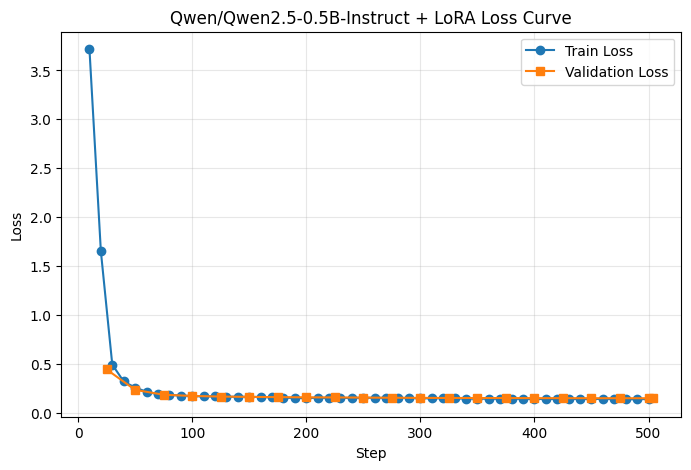

In [26]:
plot_loss_curve(dec_trainer.state.log_history,
                title=f"{decoder_model_id}{' + LoRA' if USE_LORA else ''} Loss Curve")


### 8. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Reuse `get_decoder_predictions`, but now pass `dec_trainer.model` (the fine-tuned weights). For latency/memory, write a single-example version and pass it to `measure_latency_and_memory`, just like you did for the encoder.

In [27]:
# Evaluate the FINE-TUNED decoder on the held-out test set
def predict_one_decoder(example):
    """Single-example version of get_decoder_predictions's inner loop"""
    prompt = build_prompt(example["original_text"])
    inputs = dec_tokenizer(prompt, return_tensors="pt").to(dec_trainer.model.device)
    output_ids = get_outputs(dec_trainer.model, inputs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return normalize_decoder_output(decoded)

dec_trainer.model.eval()
dec_latency, dec_peak_mem, dec_predictions = measure_latency_and_memory(
    predict_one_decoder, list(formatted_splits["test"])
)
dec_labels = [ex["category"].lower() for ex in formatted_splits["test"]]

dec_metric_dict = get_metrics(dec_labels, dec_predictions)
dec_acc, dec_prec, dec_rec, dec_f1 = (dec_metric_dict["accuracy"], dec_metric_dict["precision"],
                                       dec_metric_dict["recall"], dec_metric_dict["f1_score"])
print(dec_metric_dict)
print(f"Decoder Latency: {dec_latency:.2f} ms/query")
print(f"Decoder Peak Memory: {dec_peak_mem:.2f} MB")


{'accuracy': 0.9992559523809523, 'precision': 0.9993181818181818, 'recall': 0.9993936864471088, 'f1_score': 0.9993557285142161}
Decoder Latency: 197.98 ms/query
Decoder Peak Memory: 6313.68 MB


### 9. Required Plot: Confusion Matrix

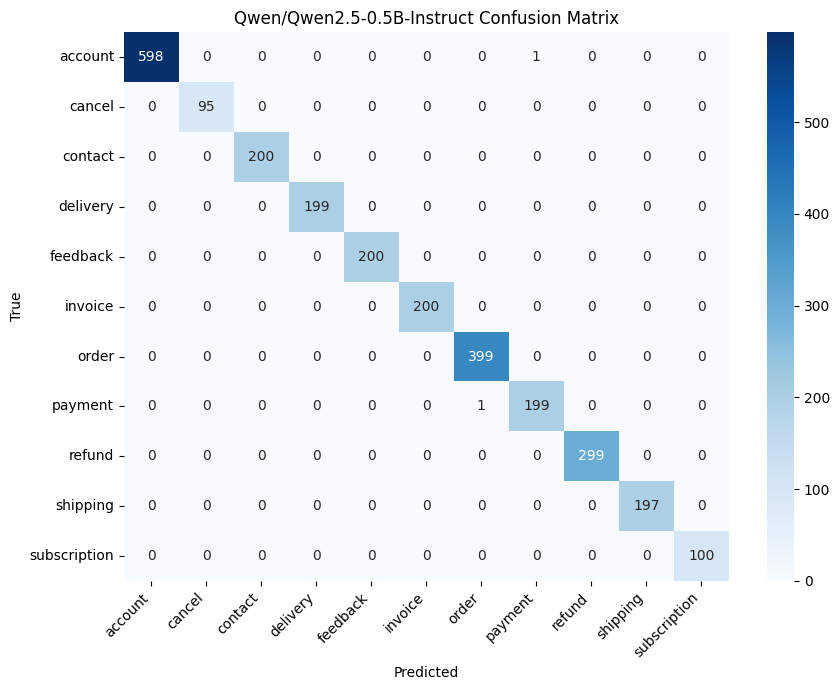

In [28]:
plot_confusion_matrix_heatmap(dec_labels, dec_predictions,
                               [c.lower() for c in TARGET_CATEGORIES],
                               title=f"{decoder_model_id} Confusion Matrix")


## 7. Comparison

Both cells below are given (pure plotting/table), they assume the variable names
used throughout this notebook (`enc_*` / `dec_*`). If you renamed anything,update the references accordingly.

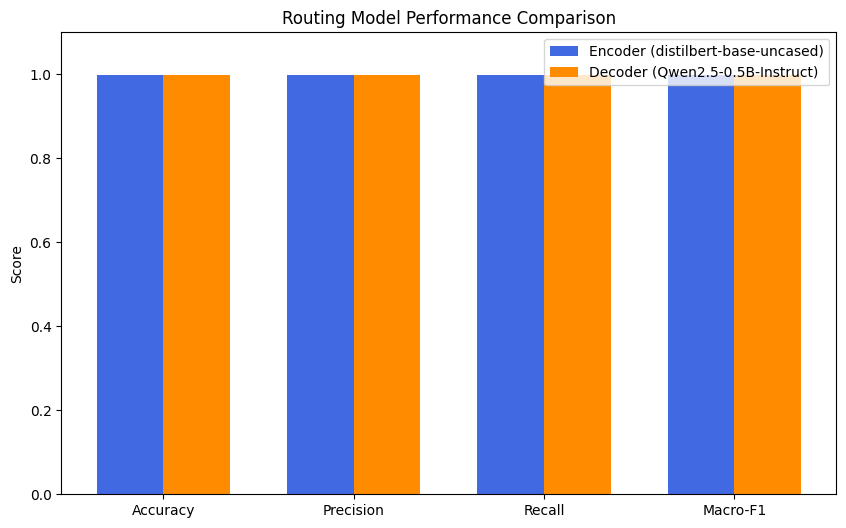

In [30]:
# Comparison bar chart
metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, enc_scores, width, label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
ax.bar(x + width/2, dec_scores, width, label=f"Decoder ({decoder_model_id.split('/')[-1]})", color="darkorange")
ax.set_ylabel("Score")
ax.set_title("Routing Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.ylim(0, 1.1)
plt.savefig('Comparision bar chart', bbox_inches='tight', dpi=150)
plt.show()



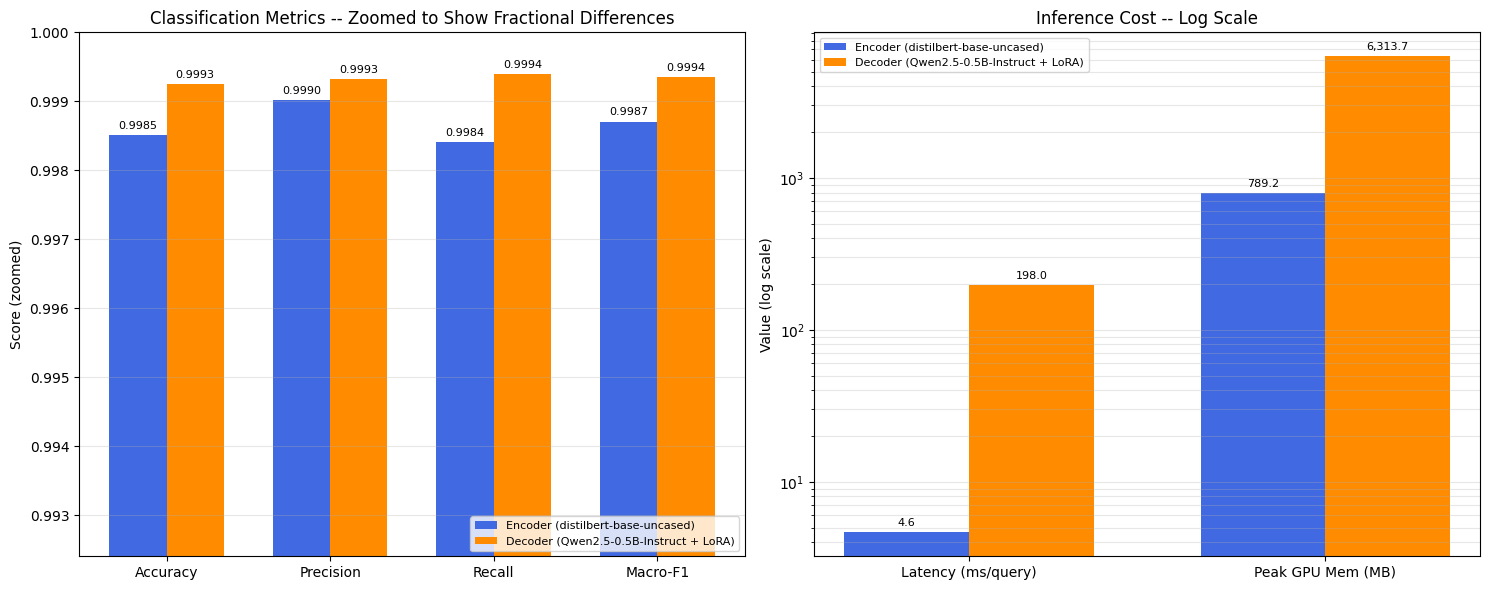

In [32]:
# A more detailed comparision chart
# Comparison bar chart -- zoomed to reveal fractional differences
# (both models score ~0.999 on a 0-1 axis, so a normal bar chart makes them
# look identical; zooming the y-axis and annotating exact values fixes that)

metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel 1: zoomed accuracy/precision/recall/F1 ---
x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax1.bar(x - width/2, enc_scores, width,
                 label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
bars2 = ax1.bar(x + width/2, dec_scores, width,
                 label=f"Decoder ({decoder_model_id.split('/')[-1]}{' + LoRA' if USE_LORA else ''})",
                 color="darkorange")

# Zoom the y-axis into the band that actually contains the scores, with a
# little headroom above the max and below the min so bars/labels aren't clipped.
all_scores = enc_scores + dec_scores
y_lo = max(0.0, min(all_scores) - 0.006)
y_hi = min(1.0, max(all_scores) + 0.004)
ax1.set_ylim(y_lo, y_hi)

# Annotate each bar with its precise 4-decimal value -- this is what actually
# shows the difference the zoomed axis alone can't fully convey.
for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax1.annotate(f"{h:.4f}", xy=(b.get_x() + b.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points",
                     ha="center", va="bottom", fontsize=8, rotation=0)

ax1.set_ylabel("Score (zoomed)")
ax1.set_title("Classification Metrics -- Zoomed to Show Fractional Differences")
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.legend(loc="lower right", fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# --- Panel 2: latency & peak memory, log scale ---
# These differ by 8-40x between models, so a shared linear axis would make
# the smaller (encoder) bars invisible -- log scale keeps both readable.
resource_names = ["Latency (ms/query)", "Peak GPU Mem (MB)"]
enc_resources = [enc_latency, enc_peak_mem]
dec_resources = [dec_latency, dec_peak_mem]

x2 = np.arange(len(resource_names))
bars3 = ax2.bar(x2 - width/2, enc_resources, width,
                 label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
bars4 = ax2.bar(x2 + width/2, dec_resources, width,
                 label=f"Decoder ({decoder_model_id.split('/')[-1]}{' + LoRA' if USE_LORA else ''})",
                 color="darkorange")

ax2.set_yscale("log")
for bars in (bars3, bars4):
    for b in bars:
        h = b.get_height()
        ax2.annotate(f"{h:,.1f}", xy=(b.get_x() + b.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points",
                     ha="center", va="bottom", fontsize=8)

ax2.set_ylabel("Value (log scale)")
ax2.set_title("Inference Cost -- Log Scale")
ax2.set_xticks(x2)
ax2.set_xticklabels(resource_names)
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(axis="y", which="both", alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_bar_chart.png', bbox_inches='tight', dpi=150)
plt.show()


In [31]:
# Dedicated comparison table with measured values
comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "Macro-F1", "Accuracy",
               "Peak GPU Memory (MB)", "Inference Latency (ms/query)"],
    f"Encoder ({encoder_model_id})": [enc_prec, enc_rec, enc_f1, enc_acc, enc_peak_mem, enc_latency],
    f"Decoder SLM ({decoder_model_id}{' + LoRA' if USE_LORA else ''})":
        [dec_prec, dec_rec, dec_f1, dec_acc, dec_peak_mem, dec_latency],
})
comparison_table


,Metric,Encoder (distilbert/distilbert-base-uncased),Decoder SLM (Qwen/Qwen2.5-0.5B-Instruct + LoRA)
0,Precision,0.999017,0.999318
1,Recall,0.998409,0.999394
2,Macro-F1,0.998707,0.999356
3,Accuracy,0.998512,0.999256
4,Peak GPU Memory (MB),789.208496,6313.682129
5,Inference Latency (ms/query),4.638098,197.982832


## 8. Recommendation
**To: Engineering Lead, ShopAssist AI**

I recommend deploying Approach 1, the fine-tuned DistilBERT encoder, for production routing. Both approaches converge to near-perfect accuracy on the held-out test set (DistilBERT: 99.87% macro-F1; Qwen2.5-0.5B + LoRA: 99.94% macro-F1), so the 0.07-point gap does not justify the decoder's cost. The encoder answers a routing request in 4.64 ms and 789 MB of peak GPU memory, versus 197.98 ms and 6,313 MB for the decoder, roughly 42x slower and 8x heavier per query. At ShopAssist's volume, that gap decides how many concurrent requests one GPU can serve, and DistilBERT is light enough to route on CPU if needed.

The main production risk is that our test set is drawn from the same Bitext distribution as training. Real customer phrasing, especially informal, multi-intent, or off-taxonomy messages like small talk, will look nothing like our clean examples, and the model will still confidently assign one of the 11 labels since it has no reject option.

To monitor this, I'd track the prediction-confidence distribution in production, route low-confidence or high-entropy predictions to a human queue, and periodically audit misrouted tickets flagged by downstream agents to catch drift early.

---


## 7. Reflection

### Q1: On what transfers from pretraining

Pretraining is the stage where a model learns general-purpose language representations, grammar, word meaning, common phrasing, and how sentences relate to each other, from a huge corpus of unlabeled text, with no notion of our 11 categories. Fine-tuning is the much shorter stage after that, where we adjust the pretrained weights (or, with LoRA, a small set of added weights) on our labeled Bitext data so the model's existing language understanding gets pointed at a specific task.

For our encoder, pretraining gave DistilBERT a `[CLS]` token that already produces a decent, general-purpose sentence embedding: it "knows" that "charged twice" and "refund" are semantically close before it has seen a single support ticket. Fine-tuning only had to learn the classification head from scratch, and nudge the pretrained embedding space so that examples from the same category cluster together and different categories separate, essentially fitting 11 decision boundaries on top of representations that already existed.

For our decoder, Qwen2.5-0.5B-Instruct's pretraining and instruction-tuning gave it fluent language understanding plus a strong prior toward writing full, polite, multi-sentence responses, visible in the 2.7% zero-shot macro-F1, where it mostly refused to just emit a bare category word. Fine-tuning had to teach it two things from scratch: the mapping from message to our specific taxonomy, and, just as importantly, how to suppress its instinct to explain itself and instead emit a single label token and stop.

### Q2: On Handling Chit-Chat Queries

If a user sends *"Hey! How's it going?"*:

**Encoder.** DistilBERT's classification head is a softmax over exactly 11 categories, so it always outputs a probability distribution that sums to 1; there is no "none of the above." For this message it will still pick whichever category scores highest (likely CONTACT or FEEDBACK, since those are the vaguest), and hand it to the wrong specialized agent with a confident-looking score, even though the true confidence should be low.

**Decoder.** Qwen was fine-tuned to always generate one of the 11 category words next, so it inherits the same forced-choice problem, but because it's a generative model, it can also degrade less predictably: it might emit a category word that loosely fits, part of a sentence, or something unrecognizable, which our `normalize_decoder_output` function then can't cleanly map to a label.

Neither approach fails gracefully in the sense of admitting uncertainty, but the decoder's failure is at least more visible: garbled or off-format output can be caught automatically as a parsing failure, whereas the encoder's confident wrong label looks identical to a correct one downstream.

For production, I'd add a 12th `OUT_OF_SCOPE` / `CHITCHAT` class trained on off-topic and small-talk examples, plus a confidence threshold: any prediction below it, from either model, gets routed to a lightweight small-talk or human-handoff agent instead of one of the 11 specialists.
